# Decision Tree Worksheet

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt
import pandas as pd


## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = pd.read_csv(url, names = names)
invalid = ['plas', 'pres', 'skin', 'test', 'mass']

X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
Y_col = 'class'

for i in invalid:
  data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)

test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[Y_col], test_size = test_size, random_state=100)
X_train, X_val , y_train, y_val = train_test_split(X_train, y_train, test_size = test_size, random_state=100)



## YOUR CODE HERE

/tmp/ipykernel_1061/1396708371.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [ ]:
## YOUR CODE HERE
decision_tree = DecisionTreeClassifier(criterion = "entropy", random_state = 100, max_depth = 100, min_samples_leaf = 4 )
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=100, min_samples_leaf=4,
                       random_state=100)

Print accuracy of training and validation data.

In [ ]:
## YOUR CODE HERE
y_train_pred = decision_tree.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train_pred, y_train)}")
y_val_pred = decision_tree.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val_pred, y_val)}")

Training Accuracy: 0.916
Validation Accuracy: 0.7301587301587301


Make a model with a low max-depth and higher minimum sample leafs.

In [ ]:
## YOUR CODE HERE
decision_tree2 = DecisionTreeClassifier(criterion = "entropy", random_state = 100, max_depth = 5, min_samples_leaf = 30 )
decision_tree2.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=30,
                       random_state=100)

Print accuracy of training and validation data.

In [ ]:
## YOUR CODE HERE
y_train_pred2 = decision_tree2.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train_pred2, y_train)}")
y_val_pred2 = decision_tree2.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val_pred2, y_val)}")

Training Accuracy: 0.796
Validation Accuracy: 0.7619047619047619


Explain the accuracy results below.

(YOUR ANSWER HERE)

The first model's high max-depth causes it to overfit the training data, leading to a higher training accuracy but lower validation accuracy compared to the second model.

## Metrics

Plot the ROC curve and print the AUC of the second model.

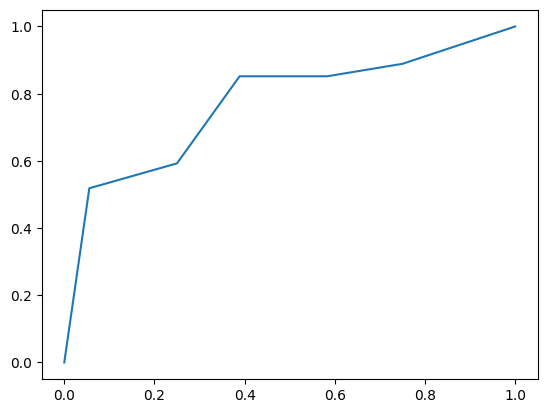

AUC: 0.7695


In [ ]:
## YOUR CODE HERE
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_val_proba2 = decision_tree2.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba2)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.show()

print(f"AUC: {roc_auc:.4f}")

Use graphviz to visualize your 2nd tree.

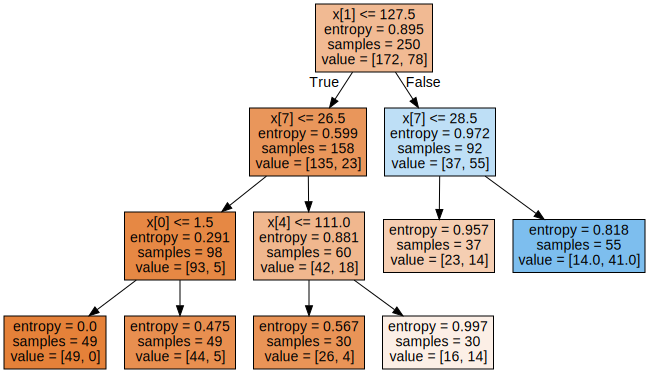

In [ ]:
## YOUR CODE HERE

dot_data = tree.export_graphviz(decision_tree2, out_file = None, filled = True)
graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

(YOUR ANSWER HERE)
They represent the data column/ feature that is being used for that particular filter.

Question 2: What is the root feature? Does it make sense as the root feature?

(YOUR ANSWER HERE)
It represents the column/feature that is being used for that particular filter.


Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

(YOUR ANSWER HERE) The training accuracy would go up due to overfitting but the testing accuracy would go down.

**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [ ]:
## YOUR CODE HERE
guess = DecisionTreeClassifier(criterion = "entropy", random_state = 100, max_depth = 500, min_samples_leaf = 1 )
guess.fit(X_train, y_train)

guess_train_pred = guess.predict(X_train)
print(f"Training Accuracy: {accuracy_score(guess_train_pred, y_train)*100}%")
guess_val_pred = guess.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(guess_val_pred, y_val)*100}%")

Training Accuracy: 100.0%
Validation Accuracy: 77.77777777777779%


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [ ]:
## YOUR CODE HERE
rf_model = RandomForestClassifier(n_estimators=100, random_state=100)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=100)

Print accuracy of training and validation data.

In [ ]:
## YOUR CODE HERE

y_train_pred = rf_model.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train_pred, y_train)}")
y_val_pred = rf_model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val_pred, y_val)}")

Training Accuracy: 1.0
Validation Accuracy: 0.7777777777777778


How did the accuracy compare to the decision tree's accuracy?

(YOUR ANSWER HERE)
Random Forest;
Training Accuracy: 1.0
Validation Accuracy: 0.7777777777777778
Decision Tree;
Training Accuracy: 0.916
Validation Accuracy: 0.7301587301587301


Print the 3 most important features (hint: sklearn has an attribute to help you find these)
Decision tree
Training Accuracy: 0.796
Validation Accuracy: 0.7619047619047619


In [ ]:
model1 = RandomForestClassifier(random_state = 88)
model1.fit(X_train, y_train)

importances = pd.Series(model1.feature_importances_, index = X_train.columns)
top3 = importances.sort_values(ascending = False).head(3)

print(f"the top 3 features are: \n{top3}")

Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

In [ ]:
tree_count = list(range(1, 101, 5))
accuracies = []

for tree in tree_count:
  model2 = RandomForestClassifier(n_estimators = tree, random_state = 88)
  model2.fit(X_train, y_train)
  predictions = model2.predict(X_val)
  accu = accuracy_score(y_val, predictions)*100

  accuracies.append(accu)

  print(f"Tree estimator count: {tree} \nAccuracy: {accu:.2f}%\n")

#plot

plt.plot(tree_count, accuracies, marker = "o", color = "b", linestyle = "-")
plt.title("random forest accuracy depending on the number of trees")
plt.xlabel("Number of trees (estimators)")
plt.ylabel("accuracy in percent")
plt.xticks(tree_count)
plt.show()

Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

In [ ]:
rf_probs = model1.predict_proba(X_val)[:,1]

fp, tp, thresholds = metrics.roc_curve(y_val, rf_probs)
auc = metrics.roc_auc_score(y_val, rf_probs)

print(f"AUC: {auc:.3f}")

plt.plot(fp, tp, label = "ROC curve")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False positive rate")
plt.ylabel("true positive rate")
plt.title("ROC Curve - Random Forest")
plt.show()